In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def visualize_trajectories(camera_file, object_file):
    # Load the CSV files
    try:
        cam_df = pd.read_csv(camera_file)
        obj_df = pd.read_csv(object_file)
    except FileNotFoundError as e:
        print(f"Error loading files: {e}")
        return

    # Initialize the 3D plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Plot Camera Trajectory
    # Estimated (Solid Black)
    ax.plot(cam_df['tx'], cam_df['ty'], cam_df['tz'], 
            label='Camera (Est)', color='black', linestyle='-', linewidth=2)
    ax.scatter(cam_df['tx'].iloc[0], cam_df['ty'].iloc[0], cam_df['tz'].iloc[0], 
           color='green', s=100, label='Start (cam)')
    ax.scatter(cam_df['tx'].iloc[-1], cam_df['ty'].iloc[-1], cam_df['tz'].iloc[-1], 
               color='orange', s=100, label='End (cam)')
    # Ground Truth (Dashed Black)
    ax.plot(cam_df['gt_tx'], cam_df['gt_ty'], cam_df['gt_tz'], 
            label='Camera (GT)', color='black', linestyle='--', linewidth=2, alpha=0.5)
    ax.scatter(cam_df['gt_tx'].iloc[0], cam_df['gt_ty'].iloc[0], cam_df['gt_tz'].iloc[0], 
           color='green', s=100)
    ax.scatter(cam_df['gt_tx'].iloc[-1], cam_df['gt_ty'].iloc[-1], cam_df['gt_tz'].iloc[-1], 
               color='orange', s=100)

    # 2. Plot Object Trajectories
    # Define distinct colors for object IDs 1 through 4
    obj_colors = {1: 'red', 2: 'green', 3: 'blue', 4: 'orange'}
    
    # Iterate through each unique object ID found in the dataset
    for obj_id in sorted(obj_df['object_id'].dropna().unique()):
        if obj_id in obj_colors:
            obj_data = obj_df[obj_df['object_id'] == obj_id]
            color = obj_colors[obj_id]
            
            # Estimated (Solid Color)
            ax.plot(obj_data['tx'], obj_data['ty'], obj_data['tz'], 
                    label=f'Object {int(obj_id)} (Est)', color=color, linestyle='-', linewidth=2)
            ax.scatter(obj_data['tx'].iloc[0], obj_data['ty'].iloc[0], obj_data['tz'].iloc[0], 
               color='cyan', s=100, label='Start (obj)')
            ax.scatter(obj_data['tx'].iloc[-1], obj_data['ty'].iloc[-1], obj_data['tz'].iloc[-1], 
               color='purple', s=100, label='End (obj)')
            # Ground Truth (Dashed Color)
            ax.plot(obj_data['gt_tx'], obj_data['gt_ty'], obj_data['gt_tz'], 
                    label=f'Object {int(obj_id)} (GT)', color=color, linestyle='--', linewidth=2, alpha=0.5)
            ax.scatter(obj_data['gt_tx'].iloc[0], obj_data['gt_ty'].iloc[0], obj_data['gt_tz'].iloc[0], 
               color='cyan', s=100)
            ax.scatter(obj_data['gt_tx'].iloc[-1], obj_data['gt_ty'].iloc[-1], obj_data['gt_tz'].iloc[-1], 
               color='purple', s=100)

    # Formatting the plot
    ax.set_title('Trajectory Visualization: Estimated vs Ground Truth', fontsize=14)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    # Place legend outside the plot to avoid covering data
    handles, labels = ax.get_legend_handles_labels()
    unique_map = dict(zip(labels, handles))
    ax.legend(unique_map.values(), unique_map.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

    # Force the axes to have an equal aspect ratio to avoid squashing the trajectory
    ax.set_box_aspect([1, 1, 1]) 
    
    plt.tight_layout()
    plt.show()




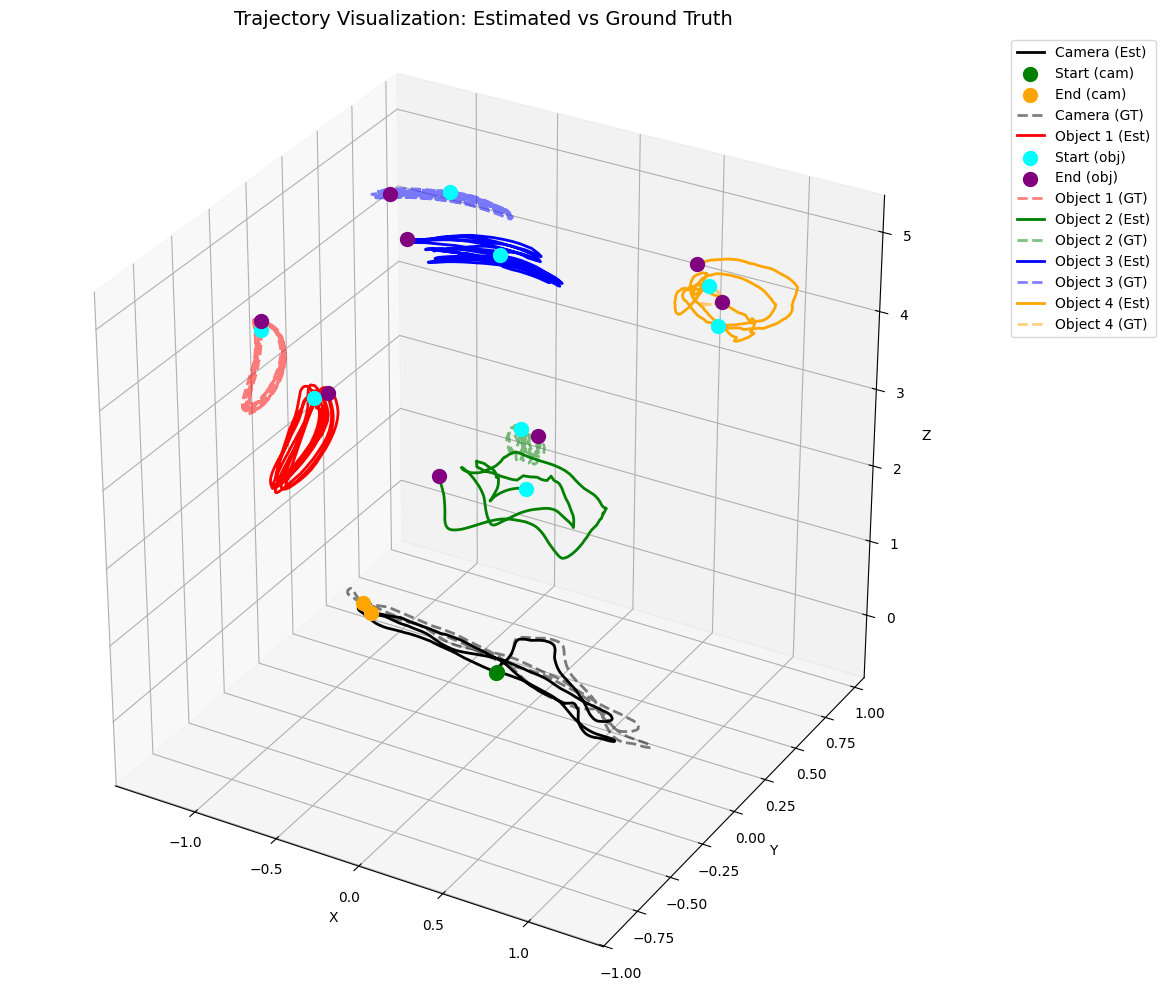

In [10]:
import os
PATH = os.getcwd()

# Note: Ensure the filenames match your local files exactly
camera_csv_path = f'{PATH}/../../results/omd_exp1/frontend_camera_pose_log.csv'
object_csv_path = f'{PATH}/../../results/omd_exp1/frontend_object_pose_log.csv'

visualize_trajectories(camera_csv_path, object_csv_path)